### Experiment preparation

In [2]:
import csv
import os

from QuantumLogistics import (
    DeltaCoarseningEngine,
    VRPExplorationsEncoder,
    VRPExplorationsSolver,
    Route,
    StandardRouteSolver,
)
from QuantumLogistics.LogisticsRoute.VrpRepGraph import vrpRepGraph
from QuantumLogistics.RouteSolver.Encoders.VRPExplorationsEncoder import VRPInstance

dataDir = os.path.join(os.getcwd(), "../../dataset")
resultsDir = os.path.join(os.getcwd(), "../../results")
csvOutputFilename = "knalecz_csvOutputFile.csv"

In [3]:
# General CMT Details: {cmt numer : (number Trucks, optimal value)}
# http://vrp.atd-lab.inf.puc-rio.br/index.php/en/
CMTDetails = {
    "01": (5, 524.61),
    "02": (10, 835.26),
    "03": (8, 826.14),
    "04": (12, 1028.42),
    "05": (17, 1291.29),
    "11": (7, 1042.12),
    "12": (10, 819.56),
}

coarseningRate = 1.0
sampleSize = 1
plotOutputs = False
numberTrucks=2
cmtNum = "01"  # http://vrp.atd-lab.inf.puc-rio.br/index.php/en/plotted-instances?data=CMT1

cmtData = CMTDetails[cmtNum]
truckNumber = cmtData[0]
cmtFile = "CMT" + cmtNum + ".xml"

inputVect = {
    "cmtFile": cmtFile,
    "numberTrucks": truckNumber,
    "CMTBKS": cmtData[1],
    "coarseningRate": coarseningRate,
    "sampleSize": sampleSize,
    "verbose": plotOutputs,
}

# Resetting csv File
with open(os.path.join(resultsDir, csvOutputFilename), "w", newline="") as csv_file:
    writer = csv.writer(csv_file, delimiter=",")
    writer.writerow(
        [
            "cmtFileName",
            "Number of Trucks",
            "Coarsening Rate",
            "Run Number",
            "Solution Cost",
            "Relative Cost",
            "Solve Time",
        ]
    )

### Graph definition

In [4]:
root = dataDir
file = os.path.join(root, cmtFile)
print(f"[i] Loading graph file {file}...")
LogisticsNetwork = vrpRepGraph(file)
LogisticsNetwork.generate_graph()

print(f"[i] Setting graph configurations for {file}...")
numberOfNodes = LogisticsNetwork.n
print(f"[i] Number of nodes {numberOfNodes} ...")

truckCapacity = max(LogisticsNetwork.nodeCapacities)
print(f"[i] Truck Capacity {truckCapacity} ...")

depot = LogisticsNetwork.nodelist.vehicle["arrival_node"]
print(f"[i] Depot Node {depot} ...")

[i] Loading graph file /home/knalecz/Pulpit/PhD/aktualne_projekty/QReaserch/graph_coarsening/21_solving-vehicle-routing-problem-and-its-variants-using-quantum-computing_b/experimentation/CMTExperiments/../../dataset/CMT01.xml...
[i] Setting graph configurations for /home/knalecz/Pulpit/PhD/aktualne_projekty/QReaserch/graph_coarsening/21_solving-vehicle-routing-problem-and-its-variants-using-quantum-computing_b/experimentation/CMTExperiments/../../dataset/CMT01.xml...
[i] Number of nodes 51 ...
[i] Truck Capacity 160.0 ...
[i] Depot Node 0 ...


### Route definiton

In [5]:
# This defines the operating details for the route (i.e number of trucks, truck capacity (how many nodes can a truck go to))
routeConfig = {
    "vehicles": numberTrucks,
    "depot": depot,
    "truckCapacity": truckCapacity,
}  # Set to -1 for auto (will evenly distribute trucks)

# Define Coarsening Object/methods
# This is if coarsening is set to true (i.e the optimiser coarsens the graph before solving)
coarsenConfig = {"coarsenRate": coarseningRate, "radiusCoefficient": 0.2}
coarseningEngine = DeltaCoarseningEngine(**coarsenConfig)

### Solver definition

In [6]:
encoder = VRPExplorationsEncoder()
solverAlg = VRPExplorationsSolver()
solver = StandardRouteSolver(encoder, solverAlg)
solverConfig = {"solver": "neal"}

### Solving

Press any to continue


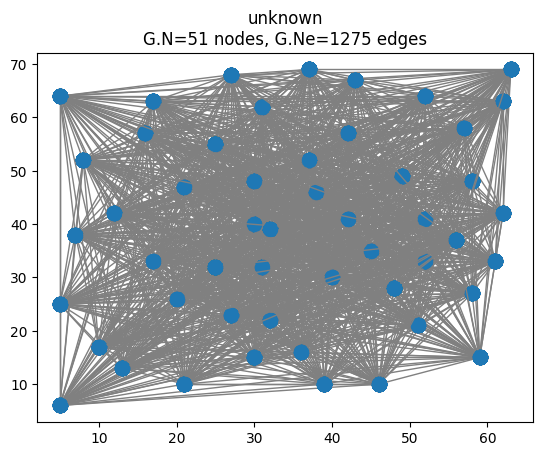

In [7]:
runNumber = 0  # TODO docelowo dodać pętlę, jak w CMT_Experiment.py

LogisticsNetwork = vrpRepGraph(file)
LogisticsNetwork.generate_graph()
LogisticsNetwork.plotGraph()

route = Route(
    LogisticsNetwork, coarseningEngine=coarseningEngine, **routeConfig
)

In [8]:
route.coarsen = (coarseningRate < 1)

solvedRoute, solveTime, cost = solver.solve(route, config=solverConfig)

IndexError: index 51 is out of bounds for axis 1 with size 51

In [ ]:
# Saving images
solutionImgFilename = f"{cmtFile}_{coarsenConfig["coarsenRate"]}_{runNumber}_solution.png"
route.visualiseSolution(solvedRoute, saveImgFilepath=os.path.join(resultsDir, solutionImgFilename))

In [ ]:
# Output
solutionList = [
    cmtFile,
    numberTrucks,
    coarsenConfig["coarsenRate"],
    runNumber,
    cost,
    cost / CMTBKS,
    solveTime,
]

with open(os.path.join(resultsDir, csvOutputFilename), "a", newline="") as csv_file:
    writer = csv.writer(csv_file, delimiter=",")
    writer.writerow(solutionList)

### Comparison with "pure" VRP-experiments solvers results

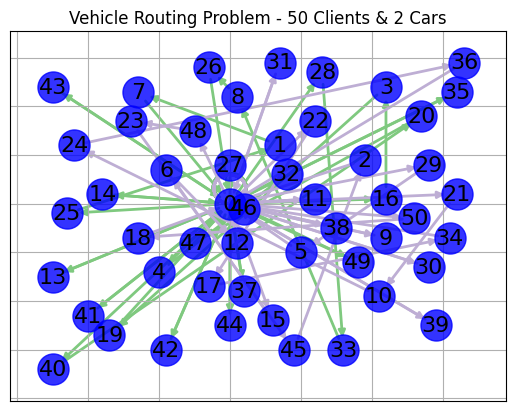

In [8]:
from VRP.quantum.BQM_based.full_qubo_solver import (
    FullQuboSolver as FQS,
    CapcFullQuboSolver as CFQS
)

vrp_instance = encoder.encode(route)
sps = FQS(
    vrp_instance.clients_num - 1,
    vrp_instance.vehicles_num,
    vrp_instance.cost_matrix
)
sps.solve(solver='neal')
sps.visualize(vrp_instance.xc, vrp_instance.yc)

In [14]:
import numpy as np

routeSol = []
for i in range(sps.solution.shape[0]):
    var_list = np.transpose(sps.variables[i]).reshape(-1)
    sol_list = np.transpose(sps.solution[i]).reshape(-1)
    active_vars = [var_list[k] for k in range(len(var_list)) if sol_list[k] == 1]
    vehicle_route = [int(var.split('.')[2]) for var in active_vars]
    edgelist = [(0, vehicle_route[0])] + [(vehicle_route[j], vehicle_route[j + 1]) for j in range(len(vehicle_route) - 1)] + [(vehicle_route[-1], 0)]
    routeSol.append(edgelist)

print(routeSol)

[[(0, 37), (37, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 13), (13, 0), (0, 4), (4, 32), (32, 0), (0, 40), (40, 20), (20, 47), (47, 0), (0, 41), (41, 0), (0, 0), (0, 35), (35, 0), (0, 25), (25, 1), (1, 7), (7, 0), (0, 28), (28, 33), (33, 8), (8, 26), (26, 0), (0, 14), (14, 0), (0, 42), (42, 0), (0, 0), (0, 44), (44, 27), (27, 0), (0, 46), (46, 49), (49, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 16), (16, 3), (3, 19), (19, 0), (0, 43), (43, 0), (0, 0)], [(0, 15), (15, 6), (6, 12), (12, 0), (0, 30), (30, 0), (0, 22), (22, 17), (17, 34), (34, 0), (0, 29), (29, 5), (5, 0), (0, 0), (0, 0), (0, 0), (0, 39), (39, 0), (0, 11), (11, 0), (0, 0), (0, 0), (0, 0), (0, 48), (48, 23), (23, 45), (45, 2), (2, 0), (0, 9), (9, 0), (0, 0), (0, 0), (0, 0), (0, 31), (31, 0), (0, 0), (0, 38), (38, 0), (0, 0), (0, 21), (21, 10), (10, 24), (24, 36), (36, 0), (0, 0), (0, 50), (50, 18), (18, 0), (0, 0), (0, 0), (0, 0)]]


In [18]:
print(solvedRoute)

[[(0, 37), (37, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 13), (13, 0), (0, 4), (4, 32), (32, 0), (0, 40), (40, 20), (20, 47), (47, 0), (0, 41), (41, 0), (0, 0), (0, 35), (35, 0), (0, 25), (25, 1), (1, 7), (7, 0), (0, 28), (28, 33), (33, 8), (8, 26), (26, 0), (0, 14), (14, 0), (0, 42), (42, 0), (0, 0), (0, 44), (44, 27), (27, 0), (0, 46), (46, 49), (49, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 16), (16, 3), (3, 19), (19, 0), (0, 43), (43, 0), (0, 0)], [(0, 15), (15, 6), (6, 12), (12, 0), (0, 30), (30, 0), (0, 22), (22, 17), (17, 34), (34, 0), (0, 29), (29, 5), (5, 0), (0, 0), (0, 0), (0, 0), (0, 39), (39, 0), (0, 11), (11, 0), (0, 0), (0, 0), (0, 0), (0, 48), (48, 23), (23, 45), (45, 2), (2, 0), (0, 9), (9, 0), (0, 0), (0, 0), (0, 0), (0, 31), (31, 0), (0, 0), (0, 38), (38, 0), (0, 0), (0, 21), (21, 10), (10, 24), (24, 36), (36, 0), (0, 0), (0, 50), (50, 18), (18, 0), (0, 0), (0, 0), (0, 0)]]
